Check: Concrete
Check: Brick
Check: Wood
Check: Glass
Check: Plywood
Check: Marble
Check: Metal
Radio Materials in scene: ['itu-very_dry_ground', 'itu-concrete', 'Concrete', 'Brick', 'Wood', 'Glass', 'Plywood', 'Marble', 'Metal']
Material: Concrete


<Figure size 800x1000 with 0 Axes>

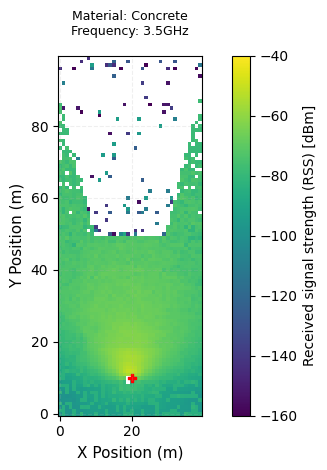

Material: Brick


<Figure size 800x1000 with 0 Axes>

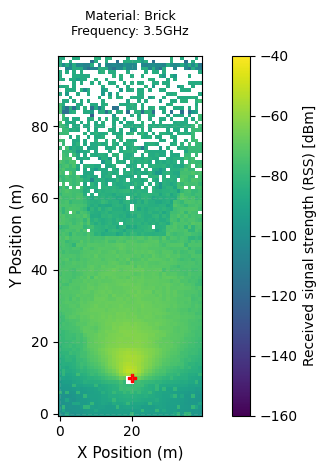

Material: Wood


<Figure size 800x1000 with 0 Axes>

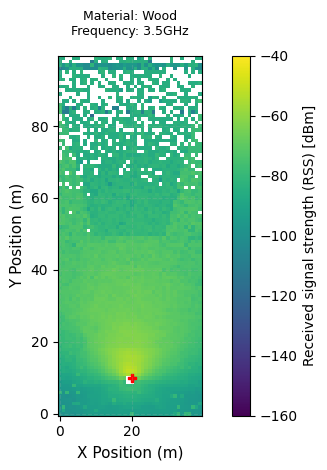

Material: Glass


<Figure size 800x1000 with 0 Axes>

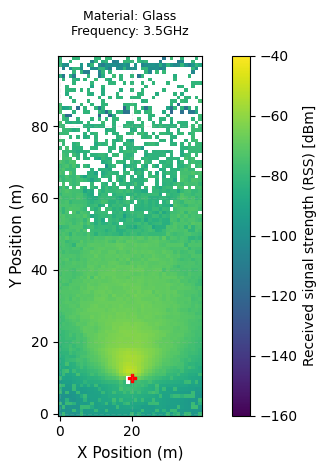

Material: Plywood


<Figure size 800x1000 with 0 Axes>

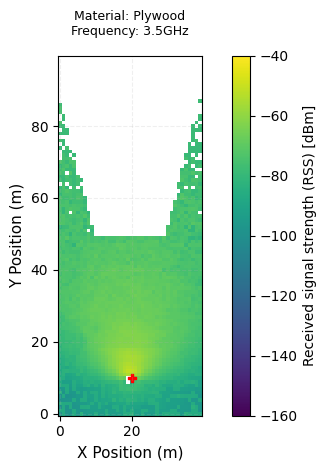

Material: Marble


<Figure size 800x1000 with 0 Axes>

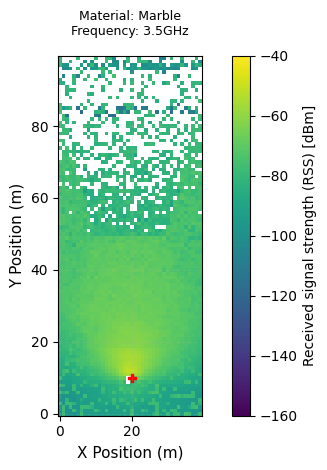

Material: Metal


<Figure size 800x1000 with 0 Axes>

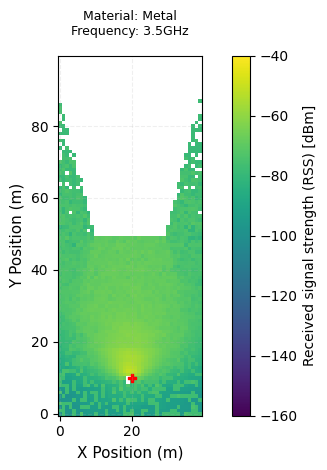

Material: Concrete, RSS = [-121.75293] dBm
Material: Brick, RSS = [-91.96423] dBm
Material: Wood, RSS = [-79.30869] dBm
Material: Glass, RSS = [-87.17419] dBm
No paths for Plywood
Material: Marble, RSS = [-79.04089] dBm
No paths for Metal


In [1]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver
import matplotlib.pyplot as plt

# Import scene from blender mitsuba export (.xml)
scene = load_scene("wall.xml")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add frequency to scene
carrier_freq = 3.5e9 # In Hz
scene.frequency = carrier_freq

# Add material to scene
scene.add(ITURadioMaterial(
    name="Concrete",
    itu_type="concrete",
    thickness=0.2
))

scene.add(ITURadioMaterial(
    name="Brick",
    itu_type="brick",
    thickness=0.2
))

scene.add(ITURadioMaterial(
    name="Wood",
    itu_type="wood",
    thickness=0.2
))

scene.add(ITURadioMaterial(
    name="Glass",
    itu_type="glass",
    thickness=0.2
))

scene.add(ITURadioMaterial(
    name="Plywood",
    itu_type="plywood",
    thickness=0.2
))

scene.add(ITURadioMaterial(
    name="Marble",
    itu_type="marble",
    thickness=0.2
))

scene.add(ITURadioMaterial(
    name="Metal",
    itu_type="metal",
    thickness=0.2
))

materials = [
    "Concrete",
    "Brick",
    "Wood",
    "Glass",
    "Plywood",
    "Marble",
    "Metal"
]

# Check if all material can be swapped for the wall
for m in materials:
    scene.objects["Cube"].radio_material = m
    print("Check:", m)

# Check current material in the scene
print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Deploy Tx and Rx location
tx = Transmitter("tx", [0, -40, 1.5], [0, 0,0], power_dbm=0)
rx = Receiver("rx", [0, 40, 1.5], [0, 0, 0])

# Point Tx and Rx towards each other
tx.look_at(rx.position)
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Generate radio map
rm_solver = RadioMapSolver()

for m in materials:

    scene.objects["Cube"].radio_material = m
    print("Material:", m)

    rm = rm_solver(
        scene,
        max_depth=10,
        samples_per_tx=10**7,
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[40, 100],
        orientation=[0, 0, 0]
    )

    plt.figure(figsize=(8, 10))

    # Show radio map
    rm.show(metric="rss")

    plt.title(
        f"Material: {m}\n"
        f"Frequency: {carrier_freq/1e9}GHz",
        fontsize=9,
        pad=15
    )

    plt.xlabel("X Position (m)", fontsize=11)
    plt.ylabel("Y Position (m)", fontsize=11)
    plt.clim(-160, -40)
    plt.grid(
        alpha=0.2,
        linestyle="--"
    )
    plt.tight_layout()
    plt.show()

# Generate paths
p_solver = PathSolver()

for m in materials:

    scene.objects["Cube"].radio_material = m

    paths = p_solver(
        scene,
        max_depth=10,
        samples_per_src=10**6
    )

    # Extract path coeficients (amplitude + phase)
    a = paths.a[0].numpy().flatten()

    # Convert path to power
    power = np.abs(a)**2 # Power = V squared or I squared assumed if R is 0

    # Skip material that does not have any path (received power = 0)
    if power.size == 0:
        print(f"No paths for {m}")
        continue

    # Generate Received Signal Strength (RSS)
    rss = 10 * np.log10(np.sum(power)) + tx.power_dbm

    print(f"Material: {m}, RSS = {rss} dBm")

In [2]:
# Preview scene (optionl)

# Select material
scene.objects["Cube"].radio_material = "Concrete"

rm_solver = RadioMapSolver()

rm = rm_solver(
        scene,
        max_depth=10, # Number of maximum interation allowed per paths
        samples_per_tx=10**7, # Number of rays launch in transmitter
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[40, 100], # Size of area to simulate (meter)
        orientation=[0, 0, 0]
    )

scene.preview(
    radio_map=rm,

    rm_metric="rss",
    rm_db_scale=True,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)